In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
np.random.seed(42)
n = 1000

cgpa = np.random.uniform(2.0, 4.0, n)
skills = np.random.randint(1, 10, n)
internships = np.random.randint(0, 5, n)
communication = np.random.randint(1, 10, n)
projects = np.random.randint(1, 6, n)

placement_score = (
    cgpa * 20 +
    skills * 5 +
    internships * 10 +
    communication * 5 +
    projects * 5 +
    np.random.randn(n) * 10
)

placement = [1 if score > 120 else 0 for score in placement_score]

df = pd.DataFrame({
    "cgpa": cgpa,
    "skills": skills,
    "internships": internships,
    "communication": communication,
    "projects": projects,
    "placement": placement
})

df.head()

,cgpa,skills,internships,communication,projects,placement
0,2.749080,8,2,9,4,1
1,3.901429,3,1,1,3,1
2,3.463988,8,1,6,1,1
3,3.197317,5,2,6,5,1
4,2.312037,1,0,5,5,0


In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cgpa           1000 non-null   float64
 1   skills         1000 non-null   int64  
 2   internships    1000 non-null   int64  
 3   communication  1000 non-null   int64  
 4   projects       1000 non-null   int64  
 5   placement      1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB
None
              cgpa       skills  internships  communication     projects  \
count  1000.000000  1000.000000  1000.000000    1000.000000  1000.000000   
mean      2.980513     4.986000     2.036000       5.019000     3.061000   
std       0.584275     2.594713     1.416584       2.586761     1.399728   
min       2.009264     1.000000     0.000000       1.000000     1.000000   
25%       2.471947     3.000000     1.000000       3.000000     2.000000   
50%       2.993615     5.000000

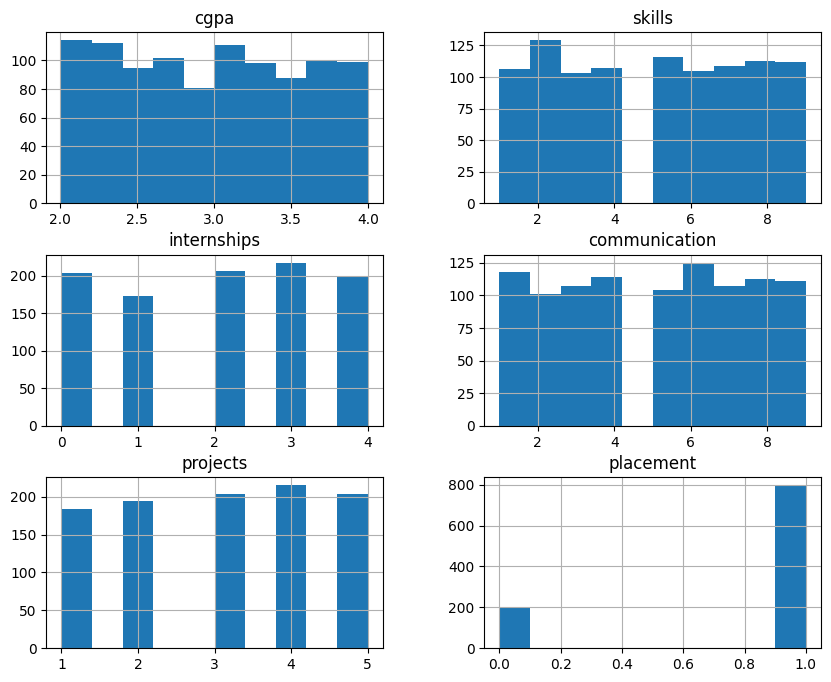

In [ ]:
df.hist(figsize=(10,8))
plt.show()

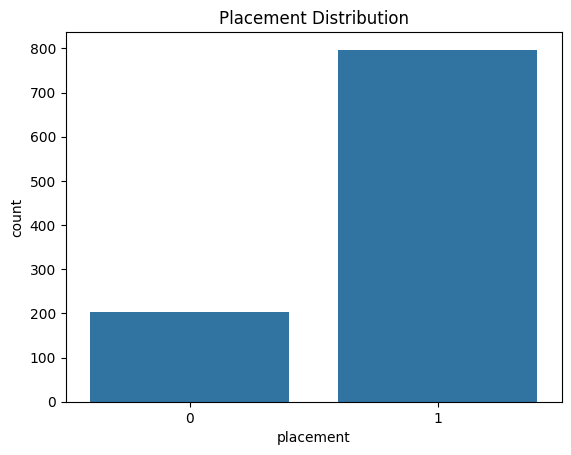

In [ ]:
sns.countplot(x='placement', data=df)
plt.title("Placement Distribution")
plt.show()

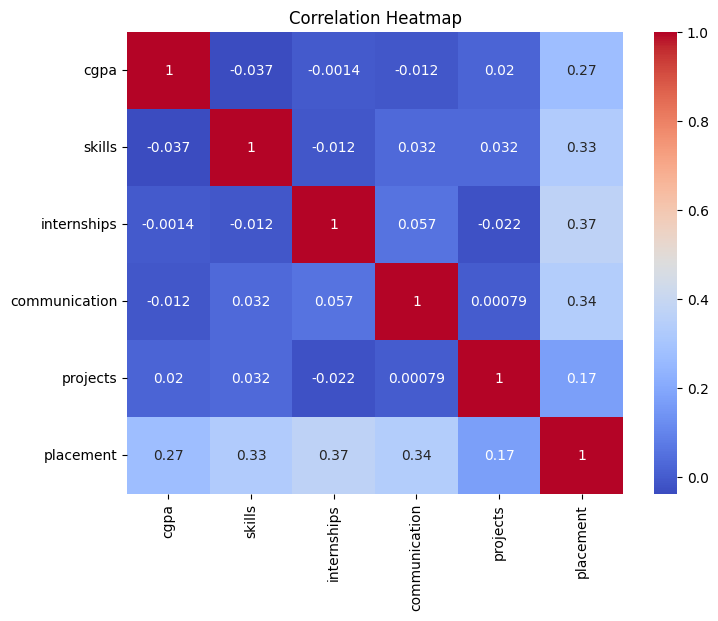

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

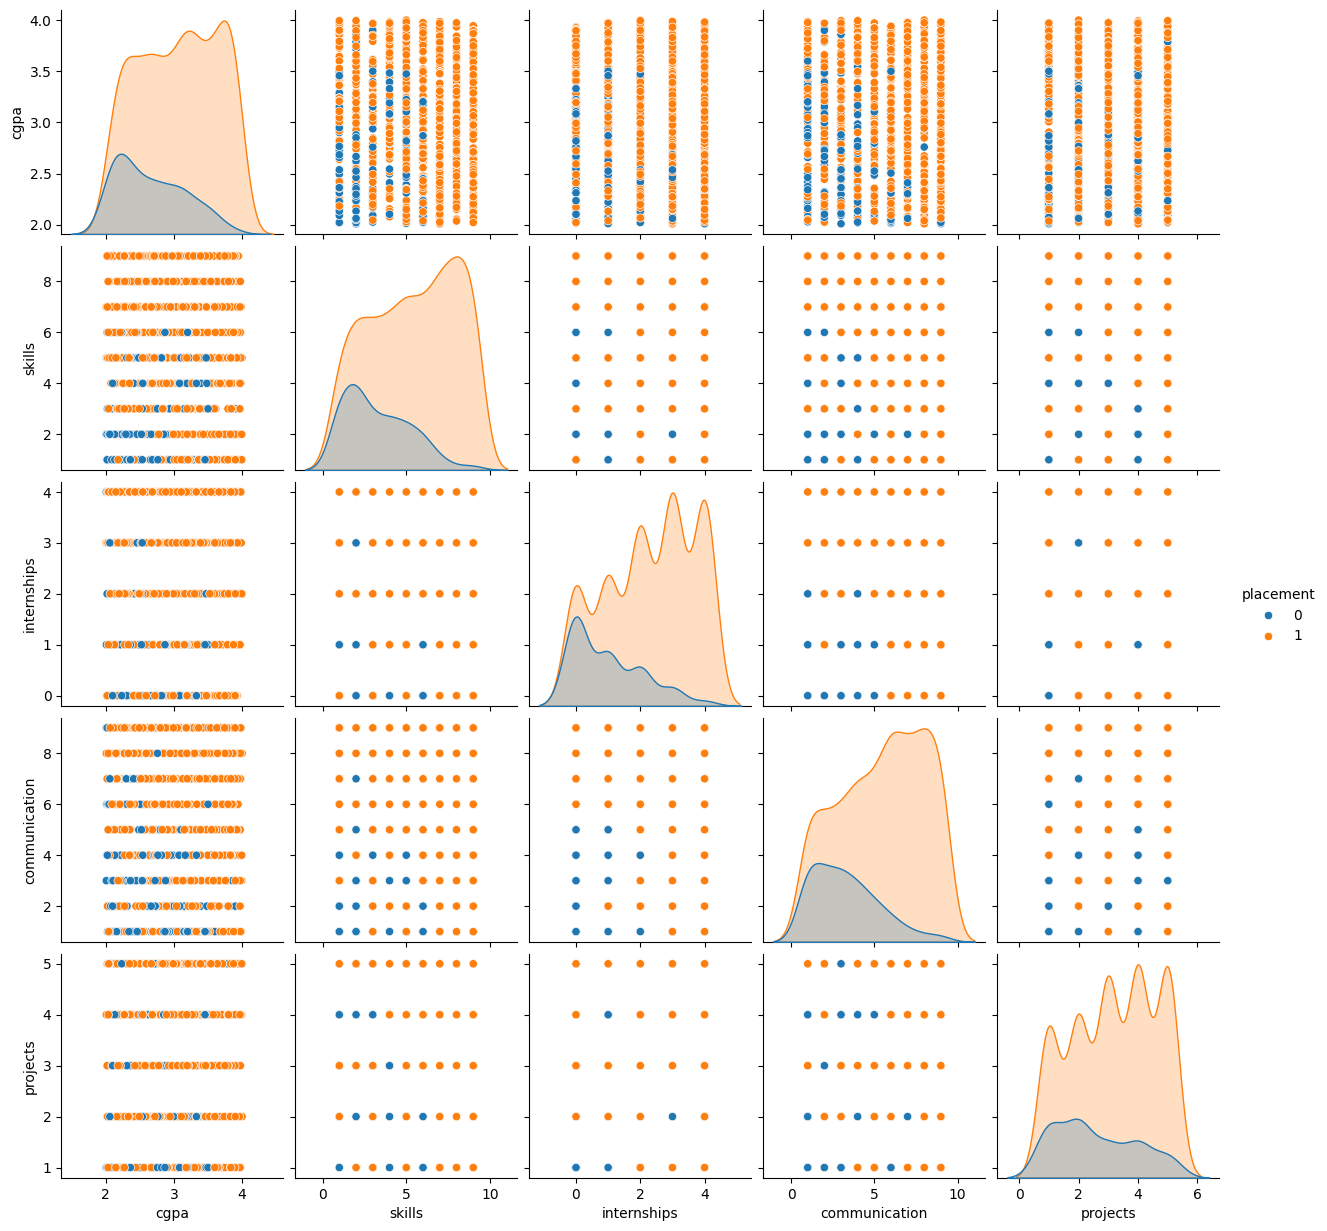

In [ ]:
sns.pairplot(df, hue='placement')
plt.show()

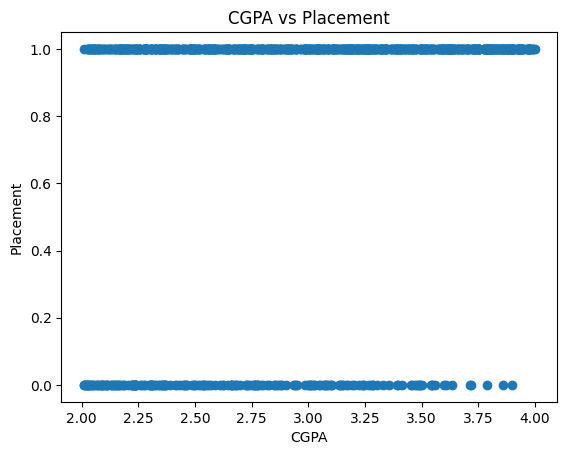

In [ ]:
plt.scatter(df['cgpa'], df['placement'])
plt.xlabel("CGPA")
plt.ylabel("Placement")
plt.title("CGPA vs Placement")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("placement", axis=1)
y = df["placement"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, pred_lr)
acc_dt = accuracy_score(y_test, pred_dt)
acc_knn = accuracy_score(y_test, pred_knn)

print("Logistic Regression Accuracy:", acc_lr)
print("Decision Tree Accuracy:", acc_dt)
print("KNN Accuracy:", acc_knn)

Logistic Regression Accuracy: 0.88
Decision Tree Accuracy: 0.835
KNN Accuracy: 0.885


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression\n", classification_report(y_test, pred_lr))
print("Decision Tree\n", classification_report(y_test, pred_dt))
print("KNN\n", classification_report(y_test, pred_knn))

Logistic Regression
               precision    recall  f1-score   support

           0       0.85      0.65      0.74        52
           1       0.89      0.96      0.92       148

    accuracy                           0.88       200
   macro avg       0.87      0.81      0.83       200
weighted avg       0.88      0.88      0.87       200

Decision Tree
               precision    recall  f1-score   support

           0       0.66      0.75      0.70        52
           1       0.91      0.86      0.89       148

    accuracy                           0.83       200
   macro avg       0.78      0.81      0.79       200
weighted avg       0.84      0.83      0.84       200

KNN
               precision    recall  f1-score   support

           0       0.82      0.71      0.76        52
           1       0.90      0.95      0.92       148

    accuracy                           0.89       200
   macro avg       0.86      0.83      0.84       200
weighted avg       0.88      0.89

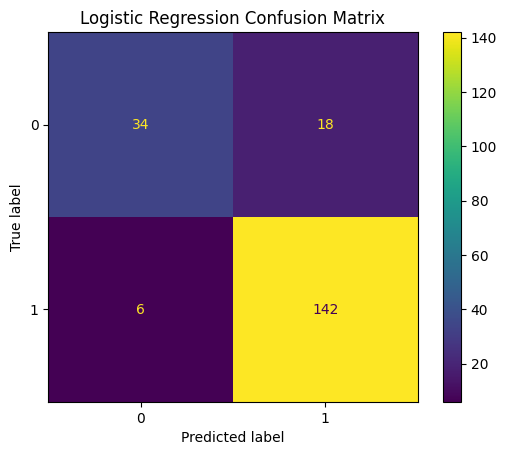

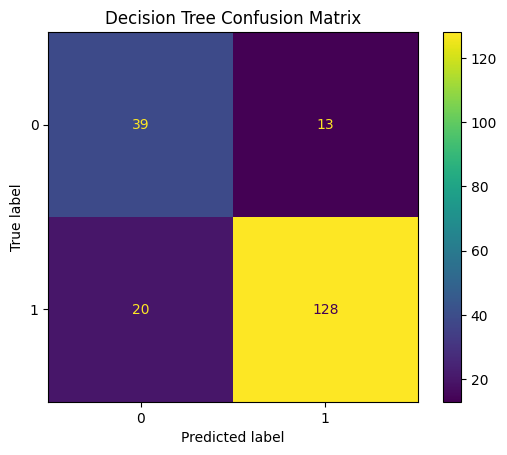

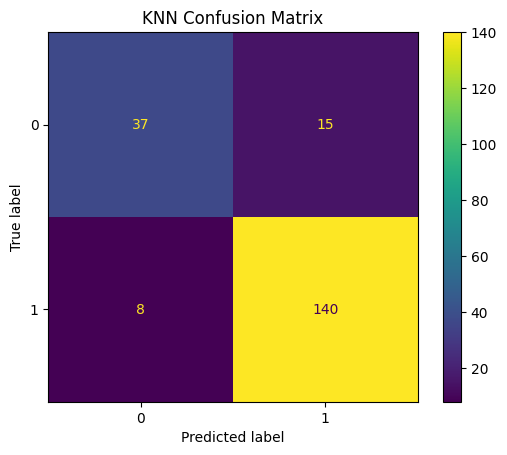

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, pred_dt)
plt.title("Decision Tree Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, pred_knn)
plt.title("KNN Confusion Matrix")
plt.show()

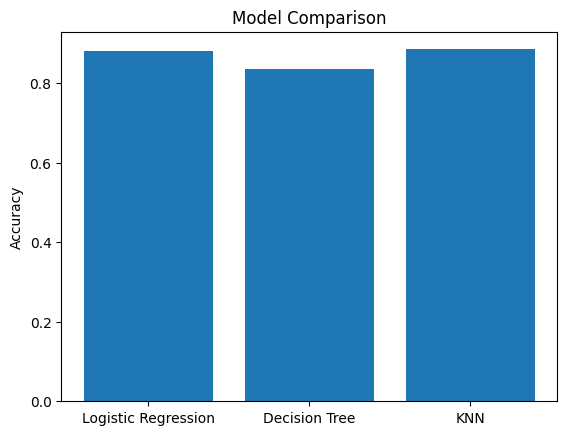

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'KNN']
scores = [acc_lr, acc_dt, acc_knn]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [3,5,7,10]}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_dt = grid.best_estimator_
pred_best_dt = best_dt.predict(X_test)

print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, pred_best_dt))

Best Parameters: {'max_depth': 10}
Tuned Decision Tree Accuracy: 0.855


In [ ]:
cgpa = float(input("Enter CGPA: "))
skills = int(input("Enter Skills (1-10): "))
internships = int(input("Enter Internships: "))
communication = int(input("Enter Communication (1-10): "))
projects = int(input("Enter Projects: "))

user_data = scaler.transform([[cgpa, skills, internships, communication, projects]])

result = lr.predict(user_data)

print("Placement Prediction:", "Placed" if result[0] == 1 else "Not Placed")

Enter CGPA: 3.13
Enter Skills (1-10): 6
Enter Internships: 2
Enter Communication (1-10): 6
Enter Projects: 42
Placement Prediction: Placed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
